In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(r"C:\Programming\Machine Learning\Used Car Price Intelligence\Used Car Arbitrage\data\raw\raw_car_listings.csv")
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual


In [44]:
df.shape

(4258, 5)

In [45]:
def clean_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().replace("₹",'').replace(',','').strip()
    if 'crore' in val or 'cr' in val:
        num = re.findall(r'[\d\.]+',val)
        return float(num[0])*10000000 if num else np.nan
    elif 'lakh' in val or 'lac' in val:
            num = re.findall(r'[\d\.]+',val)
            return float(num[0])*100000 if num else np.nan
    else:
        num = re.findall(r'[\d\.]+',val)
        if num:
            n = float(num[0])
            return n
        return np.nan

In [46]:
def clean_kilometers(val):
    if pd.isna(val):
        return np.nan

    clean_val = str(val).lower().replace('km','').replace(',','').strip()
    try:
        return float(clean_val)
    except ValueError:
        return np.nan

In [47]:
df['clean_price'] = df['Price'].apply(clean_price)

In [48]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0


In [49]:
df['clean_kms'] = df['Kilometers'].apply(clean_kilometers)

In [50]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0


In [51]:
df['Transmission'].value_counts()['Missing Transmission']

np.int64(907)

In [52]:
df['updated_transmission'] = df['Transmission'].replace("Missing Transmission",np.nan)

In [53]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual


In [54]:
df['updated_transmission'].value_counts()

updated_transmission
Manual    3351
Name: count, dtype: int64

In [55]:
df['updated_transmission'].nunique(dropna=False)

2

sirf Nan or manual transmission present hai data mai 3351(manual)+907(Nan) = 4258. Automatic hai hi nahi

In [56]:
df['Year'] = df['Title'].str.extract(r'^(\d{4})')

In [57]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020


In [58]:
df['Brand'] = df['Title'].str.extract(r'^\d{4}\s+(\w+)')

In [59]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault


In [60]:
df['Model'] = df['Title'].str.extract(r'^\d{4}\s+\w+\s+(.+)')

In [61]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata,NEXON
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault,Kwid


In [62]:
df = df.drop(['Title','Price','Kilometers','Transmission'],axis = 1)

In [63]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,Petrol,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,CNG,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,Petrol,520000.0,50912.0,Manual,2020,Tata,NEXON
4,Petrol,250000.0,68431.0,Manual,2020,Renault,Kwid


In [64]:
df['clean_price'].describe()

count    4.258000e+03
mean     4.966101e+05
std      3.799964e+05
min      4.800000e+04
25%      2.322500e+05
50%      4.000000e+05
75%      6.500000e+05
max      5.005000e+06
Name: clean_price, dtype: float64

In [65]:
df['Brand'] = df['Brand'].str.lower()
df['Model'] = df['Model'].str.lower()

In [66]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,hyundai,eon
1,Petrol,239000.0,42678.0,Manual,2017,maruti,wagon r 1.0
2,CNG,164000.0,60214.0,Manual,2018,datsun,redi go
3,Petrol,520000.0,50912.0,Manual,2020,tata,nexon
4,Petrol,250000.0,68431.0,Manual,2020,renault,kwid


In [67]:
df['Fuel_Type'].value_counts(dropna=False)

Fuel_Type
Petrol      2891
CNG          884
Diesel       458
Hybrid        14
Electric      11
Name: count, dtype: int64

In [68]:
(df.isna().mean()*100).round(2)

Fuel_Type                0.0
clean_price              0.0
clean_kms                0.0
updated_transmission    21.3
Year                     0.0
Brand                    0.0
Model                    0.0
dtype: float64

In [69]:
df['Brand'].nunique()

24

<Axes: xlabel='clean_price', ylabel='Count'>

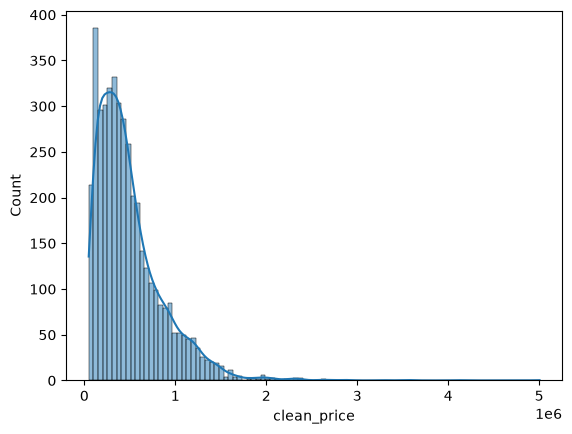

In [70]:
sns.histplot(data =df,x='clean_price',kde=True)

In [71]:
df['clean_price'].skew()

np.float64(2.300287519586333)

<Axes: xlabel='Fuel_Type', ylabel='clean_price'>

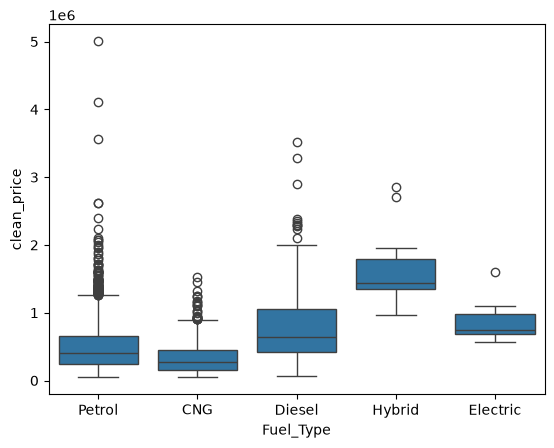

In [72]:
sns.boxplot(data = df, x='Fuel_Type',y='clean_price')

<Axes: xlabel='clean_kms', ylabel='clean_price'>

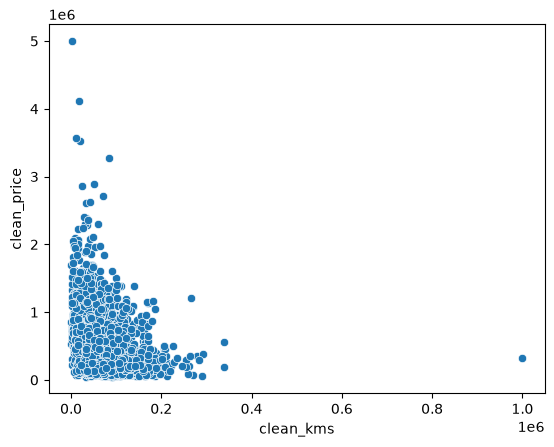

In [73]:
sns.scatterplot(data=df,x='clean_kms',y='clean_price')

In [74]:
df[df['clean_kms']>300000]

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
552,CNG,189000.0,338648.0,Manual,2016,maruti,wagon r 1.0
2283,Petrol,330000.0,999245.0,NaN,2017,maruti,baleno
4106,Diesel,567000.0,339522.0,Manual,2019,hyundai,venue


In [75]:
np.log1p(df['clean_price']).skew()

np.float64(-0.21100238410791378)

<Axes: xlabel='clean_price', ylabel='Count'>

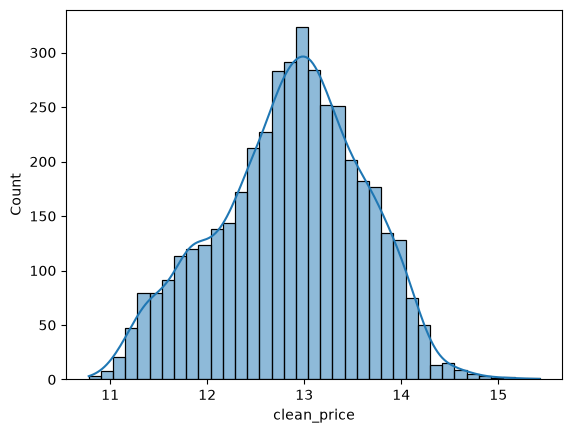

In [77]:
sns.histplot(data=df,x=np.log1p(df['clean_price']),kde=True)